In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("./Data/df_2025_limpio.csv")


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

In [5]:
df["last_review"] = pd.to_datetime(df["last_review"])


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   name                            6861 non-null   str           
 1   host_id                         6861 non-null   int64         
 2   host_name                       6861 non-null   str           
 3   neighbourhood                   6861 non-null   str           
 4   room_type                       6861 non-null   str           
 5   price                           6861 non-null   float64       
 6   minimum_nights                  6861 non-null   int64         
 7   number_of_reviews               6861 non-null   int64         
 8   last_review                     6861 non-null   datetime64[us]
 9   reviews_per_month               6861 non-null   float64       
 10  calculated_host_listings_count  6861 non-null   int64         
 11  availability_36

# Análisis univariables

### Análisis variables Categóricas

#### "room_type"

In [7]:
from bootcampviztools import pinta_distribucion_categoricas

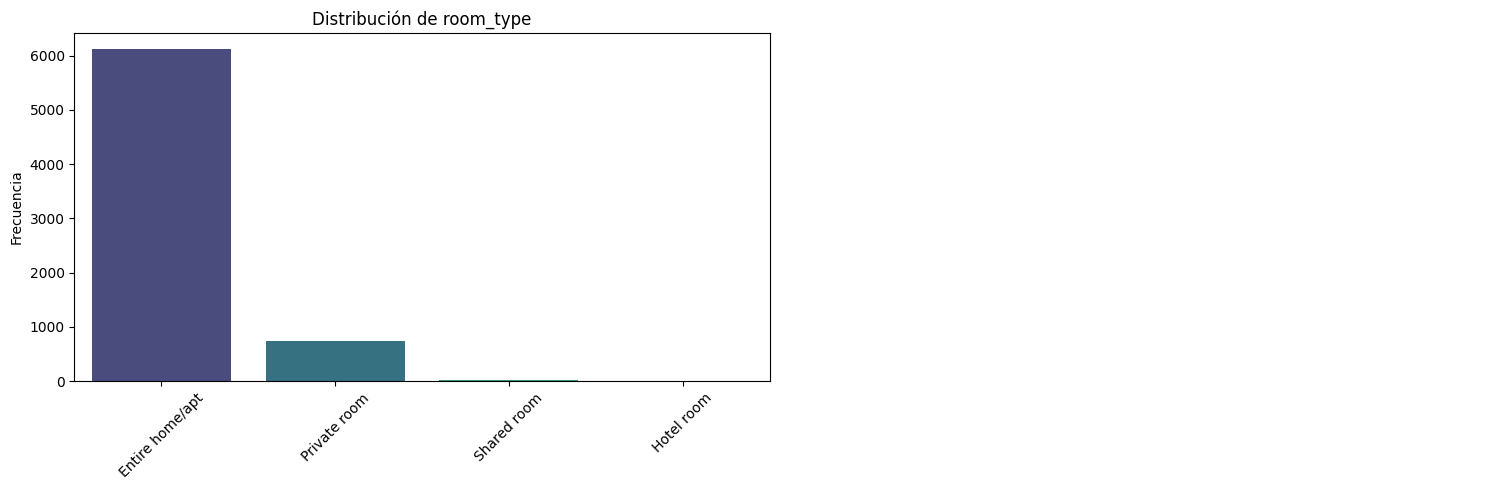

In [8]:
pinta_distribucion_categoricas(df, ["room_type"], relativa=False, mostrar_valores=False, giro = 45)

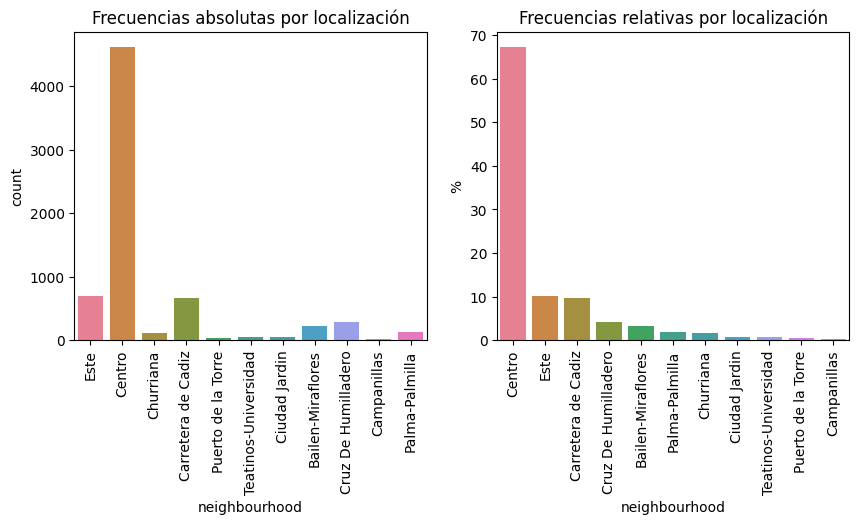

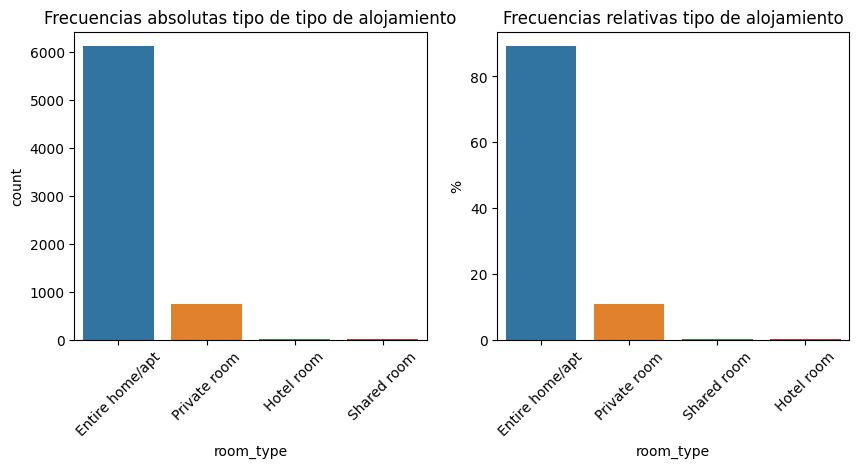

In [21]:
### BARRAS - FRECUENCIAS POR TIPO DE ALOJAMIENTOS

### Creamos figura y axes
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,4))   # Crea una figura con 1 fila y 2 columnas de subplots
fig.suptitle("")                           # Título general para toda la figura

### Countplot, nos permite frecuencias
sns.countplot(                                            
    x="room_type",                                       
    data=df,                                   
    ax=axs[0],                                             
    hue="room_type",                                    
    legend=False                                            
)
axs[0].set_title("Frecuencias absolutas tipo de tipo de alojamiento")
axs[0].tick_params(axis="x", rotation=45)

# Para frecuencias relativas... también hay que calcularlas previamente y puedes usar el barplot
valores = df.room_type.value_counts(normalize=True) * 100   # Calcula % de cada categoría

sns.barplot(                                              
    x=valores.index,                                       
    y=valores.values,                                     
    hue=valores.index,                                       
    ax=axs[1]                                               
)
axs[1].set_title("Frecuencias relativas tipo de alojamiento")        
axs[1].set_ylabel("%")
axs[1].tick_params(axis="x", rotation=45)

plt.show()  

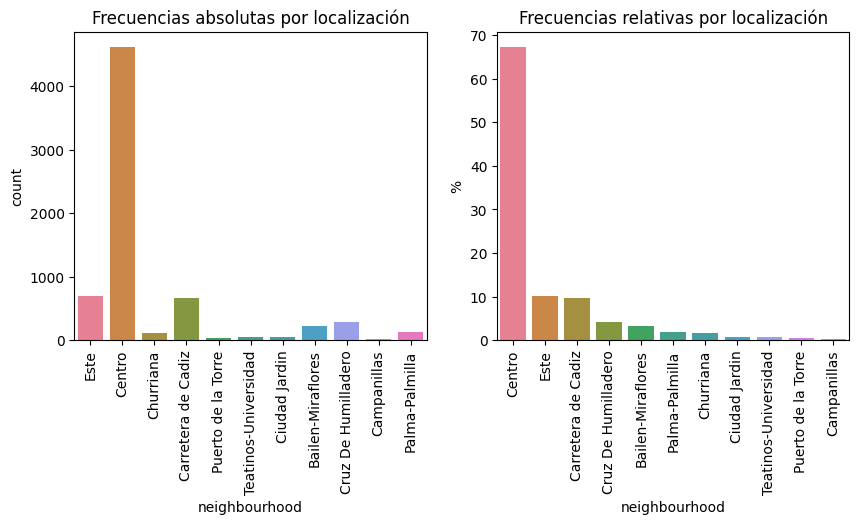

In [20]:
### BARRAS - FRECUENCIAS POR LOCALIZACIÓN

### Creamos figura y axes
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,4))   # Crea una figura con 1 fila y 2 columnas de subplots
fig.suptitle("")                           # Título general para toda la figura

### Countplot, nos permite frecuencias
sns.countplot(                                            
    x="neighbourhood",                                       
    data=df,                                   
    ax=axs[0],                                             
    hue="neighbourhood",                                    
    legend=False                                            
)
axs[0].set_title("Frecuencias absolutas por localización")
axs[0].tick_params(axis="x", rotation=90)

# Para frecuencias relativas... también hay que calcularlas previamente y puedes usar el barplot
valores = df.neighbourhood.value_counts(normalize=True) * 100   # Calcula % de cada categoría

sns.barplot(                                              
    x=valores.index,                                       
    y=valores.values,                                     
    hue=valores.index,                                       
    ax=axs[1]                                               
)
axs[1].set_title("Frecuencias relativas por localización")        
axs[1].set_ylabel("%")
axs[1].tick_params(axis="x", rotation=90)

plt.show()                                                   

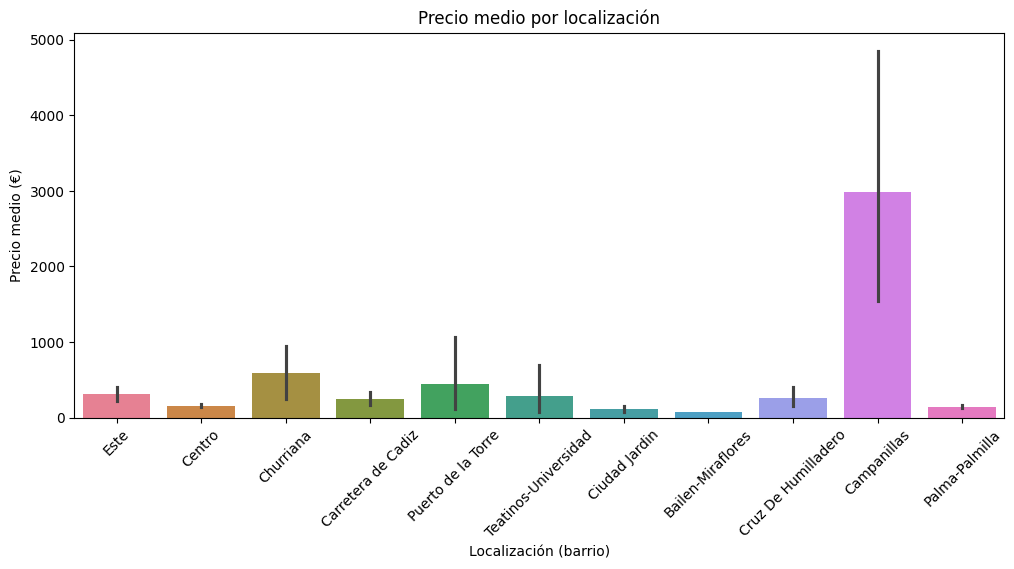

In [15]:
plt.figure(figsize=(12,5))
sns.barplot(
    x="neighbourhood",
    y="price",
    data=df,
    estimator=np.mean,
    hue="neighbourhood",
    legend=False
)
plt.title("Precio medio por localización")
plt.xlabel("Localización (barrio)")
plt.ylabel("Precio medio (€)")
plt.xticks(rotation=45)
plt.show()


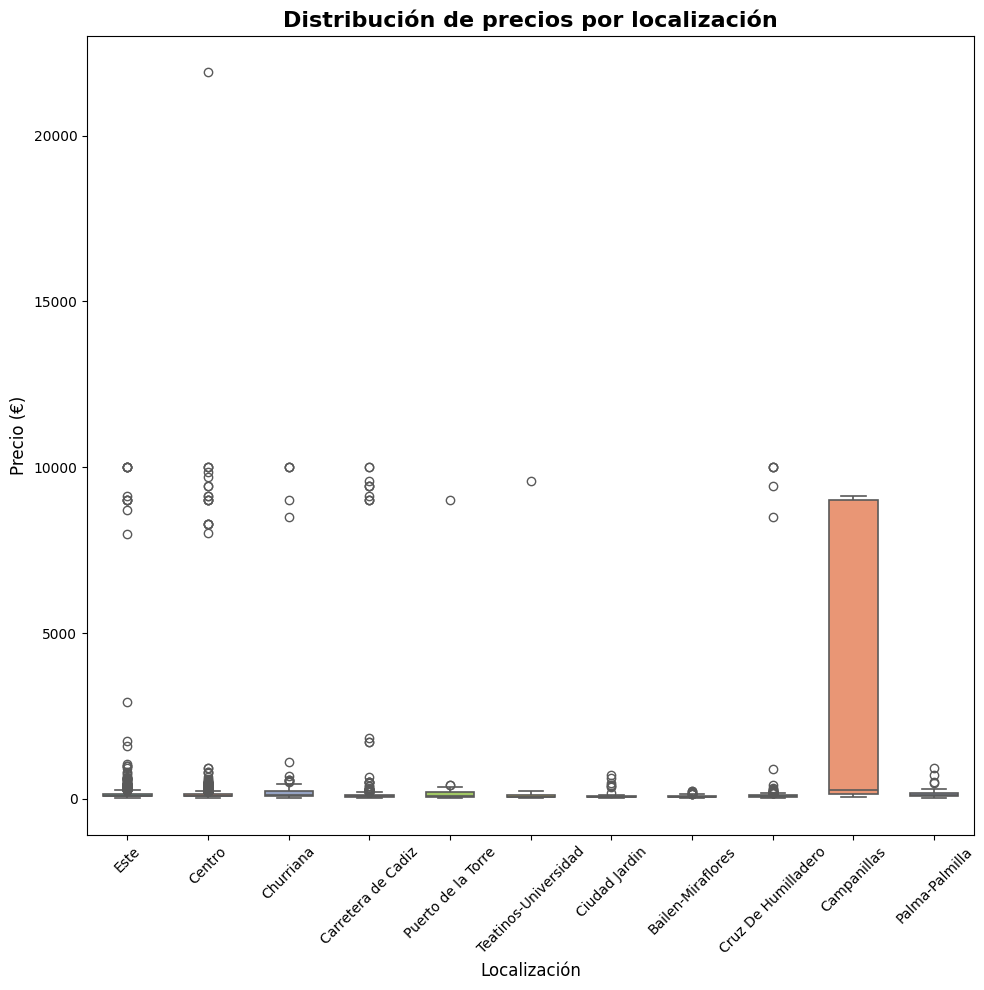

In [23]:
### DIAGRAMA DE CAJAS POR LOCALIZACIÓN Y PRECIO 

plt.figure(figsize=(10,10))   # Crea una figura grande para que el gráfico tenga espacio

sns.boxplot(
    x="neighbourhood",           
    y="price",             
    hue="neighbourhood",         
    data=df,           
    palette="Set2",          
    legend=False,             
    linewidth=1.2,            
    width=0.6                 
)

plt.title("Distribución de precios por localización",
          fontsize=16, weight="bold")   # Título del gráfico

plt.xlabel("Localización", fontsize=12)   # Etiqueta del eje X
plt.ylabel("Precio (€)", fontsize=12)     # Etiqueta del eje Y

plt.xticks(rotation=45)   # Rota las etiquetas del eje X para mejorar la lectura

plt.tight_layout()        # Ajusta márgenes para que nada quede cortado
plt.show()                # Muestra el gráfico

In [27]:
# ¿por qué campanillas tiene los precios mas caros?
# ¿Qué tipo de alojamientos tiene campanillas?

df[df["neighbourhood"]=="Campanillas"]["room_type"].value_counts()

room_type
Entire home/apt    18
Private room        1
Name: count, dtype: int64

In [ ]:
df[df["neighbourhood"]=="Campanillas"]["availability_365"].mean()

np.float64(287.2105263157895)

In [32]:
df[df["neighbourhood"]=="Campanillas"]["price"].mean()

np.float64(2989.2105263157896)

In [ ]:
# Campanillas tiene un total de 18 apartamentos completos y una habitación privada con una disponibilidad media de 287 días 
# y un precio medio de 2989 €